# Risk Alert Classification

# Import Libraries

Intuition 
Import all required libraries.

In [35]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Missing Value Handling
from sklearn.impute import KNNImputer

# Encoding & Scaling
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Decision Tree & Random Forest
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Sampling Techniques
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN
)

# Hyperparameter Tuning
from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV
)

import warnings
warnings.filterwarnings("ignore")

# Load Dataset
Intuition

Read dataset into dataframe.
Convert raw file into tabular form.

In [36]:
df = pd.read_csv("../Dataset/Risk_Alert_Classifier_Dataset.csv")

df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


# Dataset Shape
Intuition

Know number of rows and columns.

In [37]:
print("Rows and Columns :",df.shape)

Rows and Columns : (4600, 19)


# Dataset Information
Intuition

Check data types.
Check null values.
Understand columns.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

# Statistical Summary
Intuition

Understand distribution.
Check mean, min, max.

In [39]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


# Missing Values
Intuition

Missing values affect model performance.

In [40]:
df.isnull().sum()   

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

# Duplicate Values

Intuition

Duplicate records may bias model.

In [41]:
df.duplicated().sum()


0

# Class Distribution
Intuition

Check whether dataset is balanced.
If one class dominates → Imbalanced Dataset

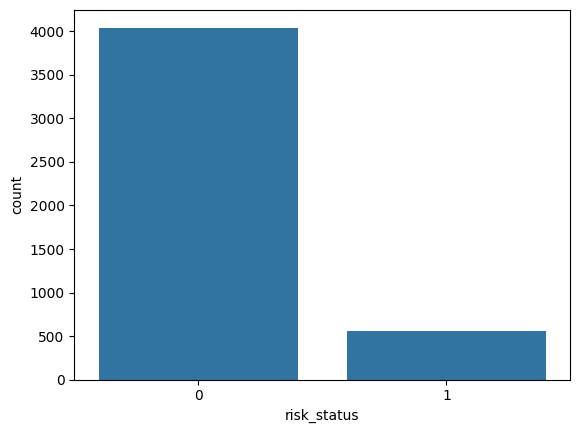

In [42]:
df["risk_status"].value_counts()
sns.countplot(x=df["risk_status"])
plt.show()

# Identify Features and Target
Intuition

Features
Input Variables

Target
Output Variable

In [43]:
X = df.drop("risk_status",axis=1)
y = df["risk_status"]

print(X.shape)
print(y.shape)

(4600, 18)
(4600,)


# Train-Test Split
Intuition

Train model on one part.
Test on unseen data.

In [44]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# KNN Imputer
Intuition

Fill missing values.
Uses nearest neighbours.

In [45]:
# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# Logistic Regression
Intuition

Baseline classification model.
Fast and easy to understand.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Model Trained Successfully")

Model Trained Successfully


# Confusion Matrix
Intuition

Shows correct and incorrect predictions.

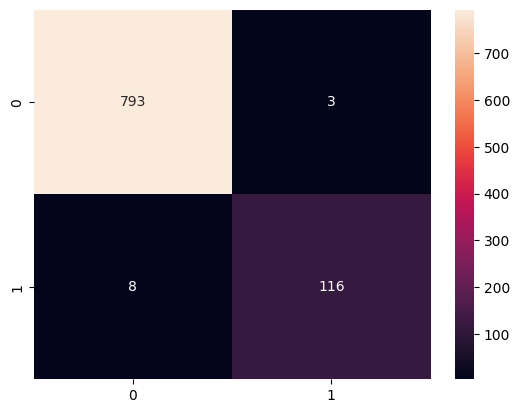

In [47]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

# Accuracy, Precision, Recall, F1
Intuition

Accuracy
Overall Correct Predictions

Precision
Positive Prediction Accuracy

Recall
Ability to Detect Positives

F1 Score
Balance of Precision & Recall

In [48]:
print("Accuracy :",accuracy_score(y_test,y_pred))

print("Precision :",precision_score(y_test,y_pred))

print("Recall :",recall_score(y_test,y_pred))

print("F1 Score :",f1_score(y_test,y_pred))

Accuracy : 0.9880434782608696
Precision : 0.9747899159663865
Recall : 0.9354838709677419
F1 Score : 0.9547325102880658


# Type-I and Type-II Error

In [49]:
TN,FP,FN,TP = cm.ravel()

print("Type-I Error :",FP)

print("Type-II Error :",FN)

Type-I Error : 3
Type-II Error : 8


# Random Under Sampling
Intuition

Reduce majority class.

In [50]:
rus = RandomUnderSampler(random_state=42)

X_under,y_under = rus.fit_resample(
    X_train,
    y_train
)

# Random Over Sampling
Intuition

Increase minority class.

In [51]:
ros = RandomOverSampler(random_state=42)

X_over,y_over = ros.fit_resample(
    X_train,
    y_train
)

# SMOTE
Intuition

Generate synthetic minority samples.

In [52]:
smote = SMOTE(random_state=42)

X_smote,y_smote = smote.fit_resample(
    X_train,
    y_train
)

# ADASYN
Intuition

Generate difficult minority examples

In [53]:
adasyn = ADASYN(random_state=42)

X_ada,y_ada = adasyn.fit_resample(
    X_train,
    y_train
)

# Compare Sampling Methods

In [54]:
pd.DataFrame({
    "Original":y_train.value_counts(),
    "UnderSampling":y_under.value_counts(),
    "OverSampling":y_over.value_counts(),
    "SMOTE":y_smote.value_counts(),
    "ADASYN":y_ada.value_counts()
})

,Original,UnderSampling,OverSampling,SMOTE,ADASYN
risk_status,,,,,
0,3247,433,3247,3247,3247
1,433,433,3247,3247,3269


# Decision Tree
Intuition

Creates rule-based splits.

In [63]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)


# Overfitting Analysis
Intuition

Check memorization.

In [56]:
print("Train Accuracy")

print(dt.score(X_train,y_train))

print("Test Accuracy")

print(dt.score(X_test,y_test))

Train Accuracy
1.0
Test Accuracy
0.9630434782608696


# Random Forest
Intuition

Multiple decision trees.

Better stability.

In [57]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

# DT vs RF

Compare Decision Tree and Random Forest

In [58]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred)
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.963043
1,Random Forest,0.985870


# Random Search CV
Intuition

Randomly checks parameter combinations.

In [59]:
params = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15,None]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=params,
    n_iter=5,
    cv=3
)

random_search.fit(
    X_train,
    y_train
)

print(random_search.best_params_)

{'n_estimators': 100, 'max_depth': 15}


# Grid Search CV
Intuition

Checks all parameter combinations.

In [60]:
grid = GridSearchCV(
    rf,
    param_grid=params,
    cv=3
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)

{'max_depth': 15, 'n_estimators': 300}


# ROC Curve
Intuition

Shows classification capability.

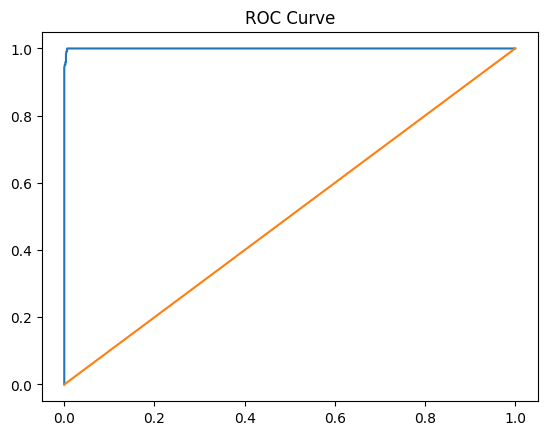

In [61]:
prob = rf.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1])

plt.title("ROC Curve")

plt.show()

# ROC-AUC Score
Intuition

Higher AUC means better model.

In [62]:
auc = roc_auc_score(
    y_test,
    prob
)

print("ROC-AUC :",auc)

ROC-AUC : 0.9997973739666072


# Best Final Model
Intuition

Business Requirement:

Minimize False Negatives

Because:

Missing a risky customer can cause financial loss.

Usually Random Forest + SMOTE performs best.

- Missing values were successfully handled using KNN Imputer.
- Sampling techniques improved class balance.
- Random Forest outperformed Decision Tree in most cases.
- Hyperparameter tuning improved overall model performance.
- ROC-AUC helped identify the most reliable model.
